In [ ]:
#Importing library
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.layers import BatchNormalization
import numpy as np

np.random.seed(1000)

In [ ]:
#Data Augmentation function
data_augmentation = keras.Sequential(
  [
    keras.layers.RandomFlip("horizontal",
                      input_shape=(32, 32, 3)),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
  ]
)
#hastag

In [ ]:
#Instantiation
AlexNet = Sequential()

In [ ]:
from keras.api._v2.keras.layers import Rescaling

#1st Convolutional Layer
AlexNet.add(data_augmentation)
AlexNet.add(Rescaling(1./255))
AlexNet.add(Conv2D(filters=96, kernel_size=(11,11), strides=(4,4), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
AlexNet.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same'))

#2nd Convolutional Layer
AlexNet.add(Conv2D(filters=256, kernel_size=(5, 5), strides=(1,1), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
AlexNet.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same'))

#3rd Convolutional Layer
AlexNet.add(Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))

#4th Convolutional Layer
AlexNet.add(Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))

#5th Convolutional Layer
AlexNet.add(Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
AlexNet.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same'))

In [ ]:
#Passing it to a Fully Connected layer
AlexNet.add(Flatten())

# 1st Fully Connected Layer
AlexNet.add(Dense(4096, input_shape=(32,32,3,)))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))

# Add Dropout to prevent overfitting
AlexNet.add(Dropout(0.4))

#2nd Fully Connected Layer
AlexNet.add(Dense(4096))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
#Add Dropout
AlexNet.add(Dropout(0.4))

#3rd Fully Connected Layer
AlexNet.add(Dense(1000))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
#Add Dropout
AlexNet.add(Dropout(0.4))

#Output Layer
AlexNet.add(Dense(10))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('softmax'))

#Model Summary
AlexNet.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 32, 32, 3)         0         
                                                                 
 rescaling (Rescaling)       (None, 32, 32, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 8, 8, 96)          34944     
                                                                 
 batch_normalization (BatchN  (None, 8, 8, 96)         384       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 8, 8, 96)          0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 4, 4, 96)         0         
 )                                                    

In [ ]:
# Compiling the model
AlexNet.compile(loss = keras.losses.sparse_categorical_crossentropy, optimizer= 'Nadam', metrics=['accuracy'])

In [ ]:
#IMAGE GENERATION 1
#Openai install, imports
!pip install openai

import os
import openai
import urllib.request
import time

# openai.api_key = os.getenv("OPENAPI_KEY")

In [ ]:
#IMAGE GENERATION 2
#Data for image generation
prompts = ["airplane", "deer", "dog", "car", "cat","frog", "horse", "bird", "ship", "truck"]
prompts2 = ["a whole airplane", "a whole deer", "a whole dog", "a whole car", "a whole cat","a whole frog", "a whole horse", "a whole bird", "a whole ship", "a whole truck"]
myPath = "/content/pictures"
os.makedirs(myPath, exist_ok=True)

In [ ]:
#IMAGE GENERATION 3
#Generating images with openai and save them
for p,p2 in zip(prompts,prompts2):
  time.sleep(15)
  newPath = os.path.join(myPath, p)
  os.makedirs(newPath, exist_ok=True)
  response = openai.Image.create(
      prompt= p2,
      n=10,
      response_format='url',
      size="256x256"
      )
  if "data" in response:
    for key, obj in enumerate(response["data"]):
      filename ='my_image_'+str(key)+".png"
      fullfilename = os.path.join(newPath, filename)
      urllib.request.urlretrieve(obj['url'], fullfilename)
    print('Images have been downloaded and saved locally')
  else:
    print("Failed to generate image")

In [ ]:
#IMAGE GENERATION 4
#Save images to drive
from google.colab import files

!zip -r /content/pictures.zip /content/pictures/

time.sleep(60)
files.download("/content/pictures.zip")

In [ ]:
#Mounting drive for the pictures
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Creating dataset from directory
import tensorflow as tf
from keras.utils import image_dataset_from_directory

pathfordata = "/content/drive/MyDrive/onlab/pics"

x_train =tf.keras.utils.image_dataset_from_directory(
    pathfordata,
    color_mode="rgb",
    batch_size=32,
    image_size=(32, 32),
    shuffle= True,
    seed = 13,
    validation_split= 0.2,
    subset = "training"
)

x_val =tf.keras.utils.image_dataset_from_directory(
    pathfordata,
    color_mode="rgb",
    batch_size=32,
    image_size=(32, 32),
    shuffle= True,
    seed = 13,
    validation_split= 0.2,
    subset = "validation"
)

y_train = x_train.class_names
y_val = x_val.class_names

print(x_train)
print(x_train.class_names)

Found 519 files belonging to 10 classes.
Using 416 files for training.
Found 519 files belonging to 10 classes.
Using 103 files for validation.
<_BatchDataset element_spec=(TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
for image_batch, labels_batch in x_train:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 32, 32, 3)
(32,)


In [ ]:
#Learning Rate Annealer
from keras.callbacks import ReduceLROnPlateau
lrr= ReduceLROnPlateau( monitor='val_accuracy',   factor=.01,   patience=3,  min_lr=1e-5)

#Defining the parameters
batch_size= 32
epochs=60
learn_rate=.001

In [ ]:
#Training the model
AlexNet.fit(x_train,
            epochs = epochs,
            validation_data = x_val,
            callbacks = [lrr],
            verbose=1)

Epoch 1/60
13/13 [==============================] - 15s 73ms/step - loss: 2.1898 - accuracy: 0.2163 - val_loss: 2.2857 - val_accuracy: 0.0971 - lr: 0.0010
Epoch 2/60
13/13 [==============================] - 0s 23ms/step - loss: 1.7750 - accuracy: 0.3462 - val_loss: 2.2976 - val_accuracy: 0.1068 - lr: 0.0010
Epoch 3/60
13/13 [==============================] - 0s 23ms/step - loss: 1.6862 - accuracy: 0.4062 - val_loss: 2.2420 - val_accuracy: 0.1553 - lr: 0.0010
Epoch 4/60
13/13 [==============================] - 0s 24ms/step - loss: 1.6066 - accuracy: 0.3942 - val_loss: 2.4143 - val_accuracy: 0.1068 - lr: 0.0010
Epoch 5/60
13/13 [==============================] - 0s 23ms/step - loss: 1.5445 - accuracy: 0.4423 - val_loss: 2.5177 - val_accuracy: 0.0971 - lr: 0.0010
Epoch 6/60
13/13 [==============================] - 0s 23ms/step - loss: 1.4921 - accuracy: 0.4928 - val_loss: 2.4841 - val_accuracy: 0.0874 - lr: 0.0010
Epoch 7/60
13/13 [==============================] - 0s 23ms/step - loss: 1.

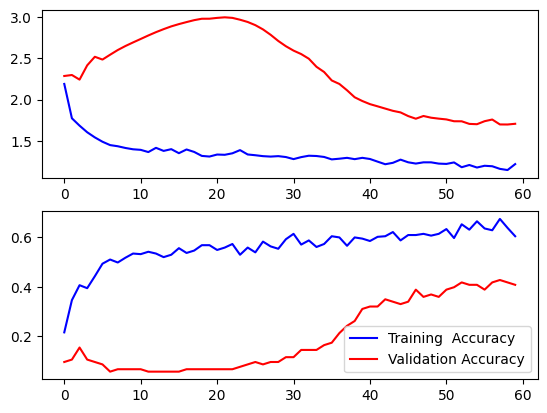

In [ ]:
#After successful training, we will visualize its performance.

import matplotlib.pyplot as plt
#Plotting the training and validation loss

f,ax=plt.subplots(2,1) #Creates 2 subplots under 1 column

#Assigning the first subplot to graph training loss and validation loss
ax[0].plot(AlexNet.history.history['loss'],color='b',label='Training Loss')
ax[0].plot(AlexNet.history.history['val_loss'],color='r',label='Validation Loss')

#Plotting the training accuracy and validation accuracy
ax[1].plot(AlexNet.history.history['accuracy'],color='b',label='Training  Accuracy')
ax[1].plot(AlexNet.history.history['val_accuracy'],color='r',label='Validation Accuracy')

plt.legend()


1/1 [==============================] - 1s 538ms/step
It was from airplane. This image most likely belongs to airplane with a 17.41 percent confidence.


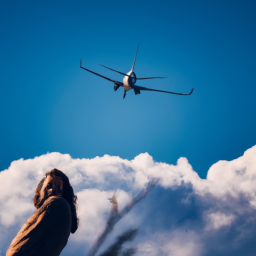

1/1 [==============================] - 0s 22ms/step
It was from bird. This image most likely belongs to bird with a 16.33 percent confidence.


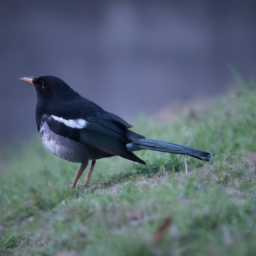

1/1 [==============================] - 0s 21ms/step
It was from car. This image most likely belongs to car with a 14.32 percent confidence.


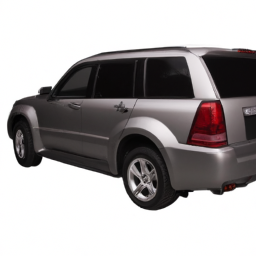

1/1 [==============================] - 0s 21ms/step
It was from cat. This image most likely belongs to frog with a 11.20 percent confidence.


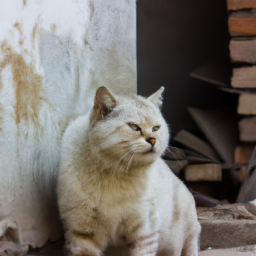

1/1 [==============================] - 0s 23ms/step
It was from deer. This image most likely belongs to cat with a 13.38 percent confidence.


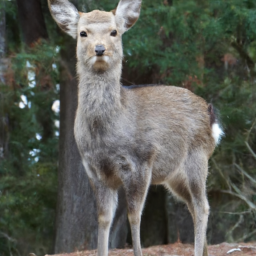

1/1 [==============================] - 0s 22ms/step
It was from dog. This image most likely belongs to horse with a 11.93 percent confidence.


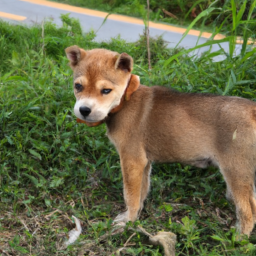

1/1 [==============================] - 0s 23ms/step
It was from frog. This image most likely belongs to cat with a 13.18 percent confidence.


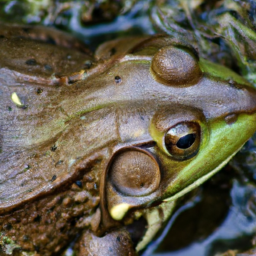

1/1 [==============================] - 0s 21ms/step
It was from horse. This image most likely belongs to horse with a 12.00 percent confidence.


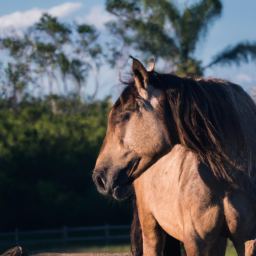

1/1 [==============================] - 0s 22ms/step
It was from ship. This image most likely belongs to dog with a 11.77 percent confidence.


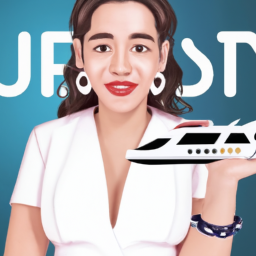

1/1 [==============================] - 0s 22ms/step
It was from truck. This image most likely belongs to cat with a 19.54 percent confidence.


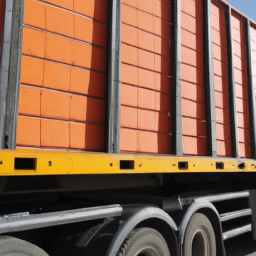

In [ ]:
# TESTING on a single image
import pathlib
from PIL import Image

airplane = '/content/drive/MyDrive/onlab/test/airplane/my_image_1.png'
car ='/content/drive/MyDrive/onlab/test/car/my_image_1.png'
cat = '/content/drive/MyDrive/onlab/test/cat/my_image_1.png'
deer = '/content/drive/MyDrive/onlab/test/deer/my_image_1.png'
dog = '/content/drive/MyDrive/onlab/test/dog/my_image_1.png'
frog = '/content/drive/MyDrive/onlab/test/frog/my_image_1.png'
horse = '/content/drive/MyDrive/onlab/test/horse/my_image_1.png'
bird = '/content/drive/MyDrive/onlab/test/bird/my_image_1.png'
ship = '/content/drive/MyDrive/onlab/test/ship/my_image_1.png'
truck = '/content/drive/MyDrive/onlab/test/truck/my_image_1.png'

directory = [airplane, bird, car, cat, deer, dog, frog, horse,  ship, truck]
directory2= ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
class_names =x_train.class_names

for d,d2 in zip(directory, directory2):
  data = pathlib.Path (d)

  img = tf.keras.utils.load_img(
      data, target_size=(32, 32)
  )
  img_array = tf.keras.utils.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0) # Create a batch

  predictions = AlexNet.predict(img_array)
  score = tf.nn.softmax(predictions[0])

  print(
       "It was from " +d2+ ". This image most likely belongs to {} with a {:.2f} percent confidence."
      .format(class_names[np.argmax(score)], 100 * np.max(score))
  )

  im = Image.open(d)
  im.show()


In [ ]:
#Defining function for confusion matrix plot
def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

#Print Confusion matrix
    fig, ax = plt.subplots(figsize=(7,7))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")
    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

np.set_printoptions(precision=2)

In [ ]:
# For RAM testing
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 89.6 gigabytes of available RAM

You are using a high-RAM runtime!


In [ ]:
#Cifar test
from keras.datasets import cifar10

(train, tainlabel),(cif_test, cif_test_label) = cifar10.load_data()

print((cif_test.shape,cif_test_label.shape))


((10000, 32, 32, 3), (10000, 1))


In [ ]:
from sklearn.utils.multiclass import unique_labels
from keras.utils import to_categorical

cif_test_label=to_categorical(cif_test_label)


In [ ]:
cif_pred=AlexNet.predict(cif_test)
cif_pred=np.argmax(cif_pred, axis=1)
cif_true=np.argmax(cif_test_label,axis=1)

313/313 [==============================] - 1s 2ms/step


In [ ]:
print(cif_pred)
print(cif_true)

[1 8 8 ... 1 3 7]
[3 8 8 ... 5 1 7]


Confusion matrix, without normalization
Normalized confusion matrix


<Axes: title={'center': 'Normalized confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

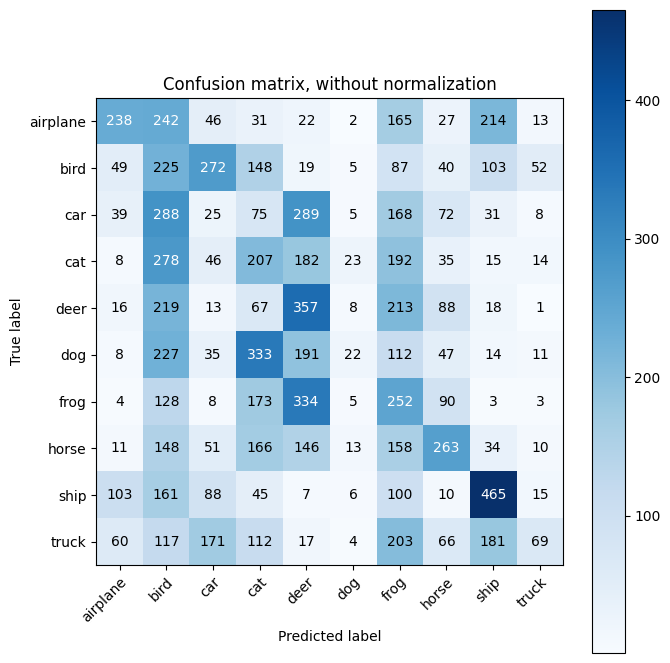

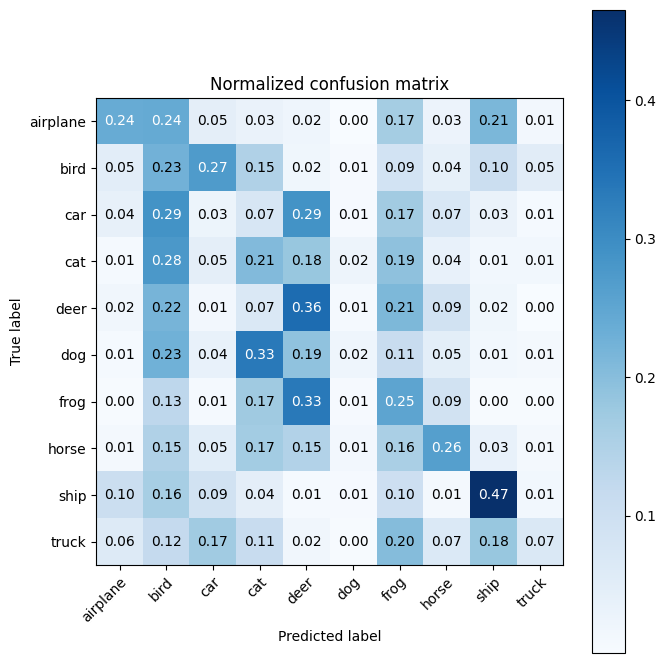

In [ ]:
#Plotting the confusion matrix
from sklearn.metrics import confusion_matrix

confusion_mtx = confusion_matrix(cif_true, cif_pred)

class_names=['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Plotting non-normalized confusion matrix
plot_confusion_matrix(cif_true, cif_pred, classes = class_names,title = 'Confusion matrix, without normalization')

# Plotting normalized confusion matrix
plot_confusion_matrix(cif_true, cif_pred, classes=class_names, normalize=True, title='Normalized confusion matrix')

In [ ]:
#Classification accuracy
from sklearn.metrics import accuracy_score
acc_score = accuracy_score(cif_true, cif_pred)
print('Accuracy Score = ', acc_score)

Accuracy Score =  0.2123
